In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
### Auckland small dataset

import pandas as pd
import requests

# 1. LOAD DATA

path = "/content/drive/MyDrive/ParkingProject/data/auckland.csv"
akl_raw = pd.read_csv(path)

print("RAW COLUMNS:", akl_raw.columns)


# 2. TIMESTAMP CLEANING

akl_raw["timestamp"] = pd.to_datetime(
    akl_raw["timestamp_utc"],
    dayfirst=True,
    errors="coerce",
    utc=True
)

print("\nNull timestamps:", akl_raw["timestamp"].isnull().sum())
akl_raw = akl_raw.dropna(subset=["timestamp"])


# 3. CARPARK LAT/LON

carpark_coords = {
    "Civic": (-36.8509, 174.7645),
    "Downtown": (-36.8480, 174.7620),
    "Ronwood": (-36.9680, 174.8760),
    "Toka Puia": (-36.8450, 174.7700),
    "Victoria Street": (-36.8502, 174.7638)
}

akl_raw["location_id"] = akl_raw["carpark"]

akl_raw["lat"] = akl_raw["location_id"].map(lambda x: carpark_coords.get(x, (None, None))[0])
akl_raw["lon"] = akl_raw["location_id"].map(lambda x: carpark_coords.get(x, (None, None))[1])

akl_raw = akl_raw.dropna(subset=["lat", "lon"])


# 4. OCCUPANCY TARGET

akl_raw["occupancy_rate"] = akl_raw["occupancy"]

# 5. TIME FEATURES

akl_raw["timestamp_hour"] = akl_raw["timestamp"].dt.floor("h")
akl_raw["date"] = akl_raw["timestamp"].dt.date

print("\nDATE CHECK:")
print("Min:", akl_raw["date"].min())
print("Max:", akl_raw["date"].max())


# 6. HOURLY AGGREGATION (GEELONG STYLE)

akl_hourly = akl_raw.groupby(
    ["timestamp_hour", "location_id", "lat", "lon"]
).agg(
    occupancy_rate=("occupancy_rate", "mean"),
    total_records=("occupancy_rate", "count")
).reset_index()


# 7. WEATHER (OPEN-METEO)

lat_akl = -36.8485
lon_akl = 174.7633

start_date = str(akl_raw["date"].min())
end_date = str(akl_raw["date"].max())

print("\nWeather range:", start_date, "→", end_date)

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat_akl,
    "longitude": lon_akl,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m,precipitation"
}

res = requests.get(url, params=params)
data = res.json()

if "hourly" not in data:
    raise ValueError(data)

weather = pd.DataFrame({
    "timestamp_hour": pd.to_datetime(data["hourly"]["time"], utc=True),
    "temperature": data["hourly"]["temperature_2m"],
    "precipitation": data["hourly"]["precipitation"]
})

weather["timestamp_hour"] = weather["timestamp_hour"].dt.floor("h")


# 8. MERGE WEATHER

akl_final = akl_hourly.merge(
    weather,
    on="timestamp_hour",
    how="left"
)


# 9. TIME FEATURES

akl_final["hour"] = akl_final["timestamp_hour"].dt.hour
akl_final["day_of_week"] = akl_final["timestamp_hour"].dt.dayofweek
akl_final["is_weekend"] = akl_final["day_of_week"].isin([5, 6]).astype(int)


# 10. RAIN FEATURES (MATCH TO GEELONG/MELBOURNE)

akl_final["is_rain"] = (akl_final["precipitation"] > 0).astype(int)

akl_final["rain_level"] = pd.cut(
    akl_final["precipitation"],
    bins=[-0.01, 0, 2, 100],
    labels=["no_rain", "light_rain", "heavy_rain"]
)

# fallback rare-class fix
rain_counts = akl_final["rain_level"].value_counts()

if "heavy_rain" in rain_counts and rain_counts["heavy_rain"] < 20:
    akl_final["rain_level"] = pd.cut(
        akl_final["precipitation"],
        bins=[-0.01, 0, 100],
        labels=["no_rain", "rain"]
    )


# 11. CLEAN WEATHER

akl_final["temperature"] = akl_final["temperature"].ffill()
akl_final["precipitation"] = akl_final["precipitation"].fillna(0)


# 12. PUBLIC HOLIDAY (NEW ZEALAND)

def get_holidays(country, years):
    all_days = []

    for y in years:
        url = f"https://date.nager.at/api/v3/PublicHolidays/{y}/{country}"
        r = requests.get(url)
        if r.status_code != 200:
            continue

        for h in r.json():
            all_days.append(h["date"])

    df = pd.DataFrame(all_days, columns=["date"])
    df["date"] = pd.to_datetime(df["date"]).dt.date
    df["is_public_holiday"] = 1
    return df

holiday_df = get_holidays("NZ", [2025])

akl_final["date"] = akl_final["timestamp_hour"].dt.date

akl_final = akl_final.merge(
    holiday_df,
    on="date",
    how="left"
)

akl_final["is_public_holiday"] = akl_final["is_public_holiday"].fillna(0).astype(int)


# 13. FINAL STRUCTURE CHECK

print("\n===== FINAL SHAPE =====")
print(akl_final.shape)

print("\n===== NULLS =====")
print(akl_final.isnull().sum())

print("\n===== TIME RANGE =====")
print("Min:", akl_final["timestamp_hour"].min())
print("Max:", akl_final["timestamp_hour"].max())

print("\n===== RAIN DISTRIBUTION =====")
print(akl_final["rain_level"].value_counts())

print("\n===== HOLIDAY DISTRIBUTION =====")
print(akl_final["is_public_holiday"].value_counts())

print("\n===== OCCUPANCY STATS =====")
print(akl_final["occupancy_rate"].describe())


# 14. SAMPLE OUTPUT

akl_final.head()

RAW COLUMNS: Index(['timestamp_utc', 'carpark', 'available_spaces', 'total_spaces',
       'occupancy', 'status', 'parking_option', 'source_last_updated'],
      dtype='object')

Null timestamps: 0

DATE CHECK:
Min: 2025-09-20
Max: 2025-10-09

Weather range: 2025-09-20 → 2025-10-09


/tmp/ipykernel_4835/1940834847.py:16: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  akl_raw["timestamp"] = pd.to_datetime(



===== FINAL SHAPE =====
(2090, 15)

===== NULLS =====
timestamp_hour       0
location_id          0
lat                  0
lon                  0
occupancy_rate       0
total_records        0
temperature          0
precipitation        0
hour                 0
day_of_week          0
is_weekend           0
is_rain              0
rain_level           0
date                 0
is_public_holiday    0
dtype: int64

===== TIME RANGE =====
Min: 2025-09-20 13:00:00+00:00
Max: 2025-10-09 07:00:00+00:00

===== RAIN DISTRIBUTION =====
rain_level
no_rain       1355
light_rain     675
heavy_rain      60
Name: count, dtype: int64

===== HOLIDAY DISTRIBUTION =====
is_public_holiday
0    1980
1     110
Name: count, dtype: int64

===== OCCUPANCY STATS =====
count    2090.000000
mean        0.342107
std         0.190006
min         0.059500
25%         0.221200
50%         0.312300
75%         0.469700
max         1.000000
Name: occupancy_rate, dtype: float64


,timestamp_hour,location_id,lat,lon,occupancy_rate,total_records,temperature,precipitation,hour,day_of_week,is_weekend,is_rain,rain_level,date,is_public_holiday
0,2025-09-20 13:00:00+00:00,Civic,-36.8509,174.7645,0.1767,1,12.3,0.0,13,5,1,0,no_rain,2025-09-20,0
1,2025-09-20 13:00:00+00:00,Downtown,-36.8480,174.7620,0.4146,1,12.3,0.0,13,5,1,0,no_rain,2025-09-20,0
2,2025-09-20 13:00:00+00:00,Ronwood,-36.9680,174.8760,0.2257,1,12.3,0.0,13,5,1,0,no_rain,2025-09-20,0
3,2025-09-20 13:00:00+00:00,Toka Puia,-36.8450,174.7700,0.0643,1,12.3,0.0,13,5,1,0,no_rain,2025-09-20,0
4,2025-09-20 13:00:00+00:00,Victoria Street,-36.8502,174.7638,0.2559,1,12.3,0.0,13,5,1,0,no_rain,2025-09-20,0


In [ ]:

# 1. IMPORTS

import pandas as pd
import numpy as np
import requests


# 2. LOAD DATA

file_path = "/content/drive/MyDrive/ParkingProject/data/auckland_detailed.csv"

df_raw = pd.read_csv(file_path)

print("\n===== RAW DATA =====")
print("Shape:", df_raw.shape)
print(df_raw.head())



# 3. CLEAN COLUMN NAMES

df_raw.columns = df_raw.columns.str.strip().str.lower()

df_raw = df_raw.rename(columns={
    "weekday_/_weekend?": "weekday_type",
    "no_of_cars": "cars",
    "no_of_available_spaces": "available_spaces"
})



# 4. TIMESTAMP

df_raw["date_parsed"] = pd.to_datetime(
    df_raw["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

df_raw["time"] = df_raw["time"].astype(str).str.strip()

df_raw["timestamp"] = pd.to_datetime(
    df_raw["date_parsed"].astype(str) + " " + df_raw["time"],
    errors="coerce"
)

df = df_raw.dropna(subset=["timestamp"]).copy()



# 5. TARGET

df["occupancy_rate"] = (df["cars"] / df["total_spaces"]).clip(0, 1)
df = df.dropna(subset=["occupancy_rate"])



# 6. LOCATION

df["location_id"] = (
    df["street"].astype(str) + "_" +
    df["section"].astype(str) + "_" +
    df["side"].astype(str)
)

df["location_encoded"] = df["location_id"].astype("category").cat.codes



# 7. TIME FEATURES

df["timestamp_hour"] = df["timestamp"].dt.floor("h")

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

# cyclic
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)



# 8. WEATHER (FIXED TIMEZONE ISSUE)

start = df["timestamp_hour"].min()
end = df["timestamp_hour"].max()

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": -36.8485,
    "longitude": 174.7633,
    "start_date": start.strftime("%Y-%m-%d"),
    "end_date": end.strftime("%Y-%m-%d"),
    "hourly": "temperature_2m,precipitation"
}

res = requests.get(url, params=params)
data = res.json()

if "hourly" not in data:
    raise ValueError("Weather API failed:", data)

weather_df = pd.DataFrame({
    "timestamp_hour": pd.to_datetime(data["hourly"]["time"]),
    "temperature": data["hourly"]["temperature_2m"],
    "precipitation": data["hourly"]["precipitation"]
})

weather_df["timestamp_hour"] = (
    weather_df["timestamp_hour"]
    .dt.tz_localize(None)
    .dt.floor("h")
)

# ensure df is same type
df["timestamp_hour"] = df["timestamp_hour"].dt.floor("h")

# merge safely
df = df.merge(weather_df, on="timestamp_hour", how="left")

# fill
df["temperature"] = df["temperature"].ffill()
df["precipitation"] = df["precipitation"].fillna(0)



# 9. WEATHER FEATURES

df["is_rain"] = (df["precipitation"] > 0).astype(int)

def rain_level(x):
    if x == 0:
        return "no_rain"
    elif x <= 2:
        return "light"
    elif x <= 5:
        return "moderate"
    else:
        return "heavy"

df["rain_level"] = df["precipitation"].apply(rain_level)



# FIXED PUBLIC HOLIDAYS


def get_nz_holidays(years):
    all_dates = []

    for y in years:
        url = f"https://date.nager.at/api/v3/PublicHolidays/{y}/NZ"
        r = requests.get(url)

        if r.status_code != 200:
            print(f"Holiday API failed for {y}")
            continue

        data = r.json()

        for h in data:
            all_dates.append(pd.to_datetime(h["date"]).date())

    return set(all_dates)


# get years
years = sorted(df["timestamp"].dt.year.unique())

holiday_dates = get_nz_holidays(years)

# create feature
df["is_public_holiday"] = df["timestamp"].dt.date.isin(holiday_dates).astype(int)

print("\nHoliday distribution FIXED:")
print(df["is_public_holiday"].value_counts())



# 11. INTERACTION FEATURES

df["hour_weekend"] = df["hour"] * df["is_weekend"]
df["rain_hour"] = df["hour"] * df["is_rain"]
df["temp_hour"] = df["hour"] * df["temperature"]



# 12. FINAL DATASET

akl_final_ready = df[[
    "timestamp_hour",
    "location_id",
    "location_encoded",
    "occupancy_rate",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "temperature",
    "precipitation",
    "is_rain",
    "rain_level",
    "is_public_holiday",
    "hour_sin",
    "hour_cos",
    "hour_weekend",
    "rain_hour",
    "temp_hour"
]].copy()



# 13. CHECKS

print("\n===== FINAL DATA =====")
print("Shape:", akl_final_ready.shape)
print("Locations:", akl_final_ready["location_id"].nunique())

print("\nOccupancy stats:")
print(akl_final_ready["occupancy_rate"].describe())

print("\nNulls:")
print(akl_final_ready.isnull().sum())

print("\nRain distribution:")
print(akl_final_ready["rain_level"].value_counts())

print("\nHoliday distribution:")
print(akl_final_ready["is_public_holiday"].value_counts())


print("\n FULL DATASET READY (WITH WEATHER + HOLIDAYS)")


===== RAW DATA =====
Shape: (29036, 17)
    daypk      pk        date  year        day      time weekday_/_weekend?  \
0  2015-1  642234  2015-08-18  2015  Weekday 1  08:00:00            weekday   
1  2015-1  642234  2015-08-18  2015  Weekday 1  08:00:00            weekday   
2  2015-1  642234  2015-08-18  2015  Weekday 1  08:00:00            weekday   
3  2015-1  642234  2015-08-18  2015  Weekday 1  08:00:00            weekday   
4  2015-1  642234  2015-08-18  2015  Weekday 1  08:00:00            weekday   

   precinct             street                                section   side  \
0         6  Wellesley St West                 Hobson St to Nelson St  north   
1         6  Wellesley St West                 Halsey St to Nelson St  north   
2         6  Wellesley St West                 Halsey St to Nelson St  south   
3         6  Wellesley St West                 Hobson St to Nelson St  south   
4         6          Hobson St  Wellesley St West to Victoria St West   west   

   

In [ ]:

# DATA PREPARATION (BOTH DATASETS)


import pandas as pd
import numpy as np

def prepare_data(df):

    df = df.copy()
    df = df.sort_values(["location_id", "timestamp_hour"])

    # ---- TIME FEATURES ----
    df["hour"] = df["timestamp_hour"].dt.hour
    df["day_of_week"] = df["timestamp_hour"].dt.dayofweek
    df["month"] = df["timestamp_hour"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # cyclic
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    # interactions
    df["hour_weekend"] = df["hour"] * df["is_weekend"]
    df["rain_hour"] = df["hour"] * df["is_rain"]
    df["temp_hour"] = df["hour"] * df["temperature"]

    # ---- TARGET ----
    df["target_next"] = df.groupby("location_id")["occupancy_rate"].shift(-1)

    # ---- LAGS ----
    df["lag_1"] = df.groupby("location_id")["occupancy_rate"].shift(1)
    df["lag_2"] = df.groupby("location_id")["occupancy_rate"].shift(2)
    df["lag_3"] = df.groupby("location_id")["occupancy_rate"].shift(3)

    df["rolling_mean_3"] = (
        df.groupby("location_id")["occupancy_rate"]
        .rolling(3).mean().reset_index(0, drop=True)
    )

    # ---- CLEAN ----
    df = df.dropna()

    return df


# apply
akl_big = prepare_data(akl_final_ready)
akl_small = prepare_data(akl_final)

print("Big:", akl_big.shape)
print("Small:", akl_small.shape)

Big: (24263, 23)
Small: (2070, 26)


In [ ]:

# LOCATION ENCODING


from sklearn.preprocessing import LabelEncoder

# FIT ON BIG DATA
le = LabelEncoder()
akl_big["location_encoded"] = le.fit_transform(akl_big["location_id"])

# CREATE  MAP
location_map = dict(zip(le.classes_, le.transform(le.classes_)))

# APPLY TO SMALL DATASET
akl_small["location_encoded"] = akl_small["location_id"].map(location_map)

# unseen locations to -1
akl_small["location_encoded"] = akl_small["location_encoded"].fillna(-1)


# RAIN ENCODING
rain_map = {"no_rain": 0, "light": 1, "moderate": 2}

akl_big["rain_level"] = akl_big["rain_level"].map(rain_map).fillna(0)
akl_small["rain_level"] = akl_small["rain_level"].map(rain_map).fillna(0)


# FEATURES
features = [
    "location_encoded",
    "hour","day_of_week","month","is_weekend",
    "temperature","precipitation","is_rain","rain_level",
    "hour_sin","hour_cos","hour_weekend","rain_hour","temp_hour",
    "lag_1","lag_2","lag_3","rolling_mean_3"
]

target = "target_next"

In [ ]:

# TRAIN MODEL (GLOBAL MODEL)


from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# TRAIN / TEST SPLIT
split = int(len(akl_big) * 0.8)

train = akl_big.iloc[:split]
test  = akl_big.iloc[split:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


# MODEL
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)


# EVALUATION
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\n===== BIG DATA MODEL =====")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Pseudo Accuracy: {(1-mae)*100:.2f}%")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 19410, number of used features: 18
[LightGBM] [Info] Start training from score 0.794727
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [ ]:

# PROPER TIME-BASED VALIDATION (SMALL DATASET)


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# SORTING FIRST
akl_small = akl_small.sort_values(["location_id", "timestamp_hour"])



# 4.1 TIME-BASED SPLIT PER LOCATION


train_parts = []
test_parts = []

for loc in akl_small["location_id"].unique():

    loc_df = akl_small[akl_small["location_id"] == loc]

    split = int(len(loc_df) * 0.7)

    train_parts.append(loc_df.iloc[:split])
    test_parts.append(loc_df.iloc[split:])

train_small = pd.concat(train_parts)
test_small  = pd.concat(test_parts)



# 4.2 FEATURES

X_test_small = test_small[features]
y_test_small = test_small[target]



# 4.3 PREDICT

pred_small = model.predict(X_test_small)



# 4.4 METRICS

mae_s = mean_absolute_error(y_test_small, pred_small)
rmse_s = np.sqrt(mean_squared_error(y_test_small, pred_small))

print("\n===== SMALL DATA (TIME-BASED VALIDATION) =====")
print(f"MAE: {mae_s:.4f}")
print(f"RMSE: {rmse_s:.4f}")
print(f"Pseudo Accuracy: {(1-mae_s)*100:.2f}%")



# 4.5 SAMPLE OUTPUT

sample = pd.DataFrame({
    "actual": y_test_small.values[:10],
    "predicted": pred_small[:10]
})

print("\n=== SAMPLE (TIME-BASED) ===")
print(sample)



# 4.6 LOCATION-WISE ERROR

test_small["pred"] = pred_small

print("\n===== LOCATION-WISE MAE =====")
print(
    test_small.groupby("location_id")
    .apply(lambda x: np.mean(np.abs(x["target_next"] - x["pred"])))
)




===== SMALL DATA (TIME-BASED VALIDATION) =====
MAE: 0.1214
RMSE: 0.1470
Pseudo Accuracy: 87.86%

=== SAMPLE (TIME-BASED) ===
   actual  predicted
0  0.2155   0.391900
1  0.2554   0.418031
2  0.2909   0.398137
3  0.3675   0.474229
4  0.4224   0.482539
5  0.7478   0.515161
6  0.8588   0.603645
7  0.7877   0.708134
8  0.6002   0.678890
9  0.7597   0.646980

===== LOCATION-WISE MAE =====
location_id
Civic              0.134742
Downtown           0.105221
Ronwood            0.139163
Toka Puia          0.130290
Victoria Street    0.097468
dtype: float64


/tmp/ipykernel_4835/382670339.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.mean(np.abs(x["target_next"] - x["pred"])))


In [ ]:

# TRAIN NO-LAG MODEL (FALLBACK MODEL)


features_nolag = [
    "location_encoded",
    "hour","day_of_week","month","is_weekend",
    "temperature","precipitation","is_rain","rain_level",
    "hour_sin","hour_cos","hour_weekend","rain_hour","temp_hour"
]

X_train_nolag = train[features_nolag]
y_train_nolag = train[target]

from lightgbm import LGBMRegressor

model_nolag = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

model_nolag.fit(X_train_nolag, y_train_nolag)


# quick check
pred_nolag = model_nolag.predict(test[features_nolag])

from sklearn.metrics import mean_absolute_error
print("\nNO-LAG MODEL MAE:", mean_absolute_error(test[target], pred_nolag))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 19410, number of used features: 14
[LightGBM] [Info] Start training from score 0.794727
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:

# FINAL REAL-TIME PREDICTION (WITH FALLBACK MODEL)


import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
from datetime import timedelta



name_fix_map = {
    "Victoria St": "Victoria Street"
}



# 2. TOTAL SPACES

total_spaces_map = {
    "Civic": 930,
    "Ronwood": 678,
    "Toka Puia": 420,
    "Victoria Street": 895
}



# 3. FETCH LIVE DATA

url = "https://at.govt.nz/umbraco/surface/parkingavailabilitysurface/ParkingAvailabilityResult"

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

rows = soup.find_all("div", class_="divTableRow")

data = []

for row in rows:
    cells = row.find_all("div", class_="divTableCell")

    if len(cells) < 3:
        continue

    location = cells[0].get_text(strip=True)
    ptype = cells[1].get_text(strip=True)
    available = cells[2].get_text(strip=True)

    if location == "Car park":
        continue

    if ptype != "Short-term":
        continue

    try:
        available = int(available)
    except:
        continue

    location = name_fix_map.get(location, location)

    data.append({
        "location_id": location,
        "available_spaces": available
    })

live_df = pd.DataFrame(data)

print("\n===== LIVE DATA =====")
print(live_df)



# 4. FILTER TARGET LOCATIONS

live_df = live_df[live_df["location_id"].isin(total_spaces_map.keys())]



# 5. OCCUPANCY

live_df["total_spaces"] = live_df["location_id"].map(total_spaces_map)

live_df["occupancy_now"] = 1 - (live_df["available_spaces"] / live_df["total_spaces"])
live_df["occupancy_now"] = live_df["occupancy_now"].clip(0, 1)



# 6. TIME FEATURES

now = pd.Timestamp.now().floor("h")
future = now + timedelta(hours=1)

live_df["hour"] = future.hour
live_df["day_of_week"] = future.dayofweek
live_df["month"] = future.month
live_df["is_weekend"] = 1 if future.dayofweek >= 5 else 0

live_df["hour_sin"] = np.sin(2*np.pi*live_df["hour"]/24)
live_df["hour_cos"] = np.cos(2*np.pi*live_df["hour"]/24)

live_df["hour_weekend"] = live_df["hour"] * live_df["is_weekend"]



# 7. WEATHER (USING LAST FROM TRAINING DATA)

latest = akl_big.sort_values("timestamp_hour").iloc[-1]

rain_map = {"no_rain": 0, "light": 1, "moderate": 2}

live_df["temperature"] = latest["temperature"]
live_df["precipitation"] = latest["precipitation"]
live_df["is_rain"] = latest["is_rain"]
live_df["rain_level"] = rain_map.get(latest["rain_level"], 0)

live_df["rain_hour"] = live_df["hour"] * live_df["is_rain"]
live_df["temp_hour"] = live_df["hour"] * live_df["temperature"]



# 8. LOCATION ENCODING

location_map = dict(zip(le.classes_, le.transform(le.classes_)))

live_df["location_encoded"] = live_df["location_id"].map(location_map).fillna(-1)



# 9. NO-LAG FEATURES (FALLBACK MODEL)

features_nolag = [
    "location_encoded",
    "hour","day_of_week","month","is_weekend",
    "temperature","precipitation","is_rain","rain_level",
    "hour_sin","hour_cos","hour_weekend","rain_hour","temp_hour"
]

X_live = live_df[features_nolag]



# 10. PREDICT USING SAME MODEL (WITHOUT LAGS)

pred = model_nolag.predict(X_live)



# 11. STABILITY ADJUSTMENTS

max_change = 0.2 + 0.3 * live_df["is_weekend"]

pred = np.clip(
    pred,
    live_df["occupancy_now"] - max_change,
    live_df["occupancy_now"] + max_change
)

live_df["predicted_next_hour"] = pred



# 12. VEHICLE COUNT

live_df["predicted_cars"] = (
    live_df["predicted_next_hour"] *
    live_df["total_spaces"]
).round(0)



# 13. OUTPUT

print("\n==============================")
print(" FINAL REAL-TIME PREDICTION")
print("==============================")

print(live_df[[
    "location_id",
    "occupancy_now",
    "predicted_next_hour",
    "predicted_cars"
]])


===== LIVE DATA =====
       location_id  available_spaces
0    Albert Street                 0
1            Civic               531
2         Downtown                 0
3          Ronwood               528
4        Toka Puia               305
5  Victoria Street               548

 FINAL REAL-TIME PREDICTION
       location_id  occupancy_now  predicted_next_hour  predicted_cars
1            Civic       0.429032             0.416387           387.0
3          Ronwood       0.221239             0.416387           282.0
4        Toka Puia       0.273810             0.416387           175.0
5  Victoria Street       0.387709             0.416387           373.0


In [ ]:

# OTHER LOCATIONS PREDICTION

import pandas as pd
import numpy as np
from datetime import timedelta



# 1. TIME SETUP

latest_time = akl_big["timestamp_hour"].max()
future_time = latest_time + timedelta(hours=1)



# 2. BASE DATA

all_locations = akl_big["location_id"].unique()

df_other = pd.DataFrame({
    "location_id": all_locations
})



# 3. APPROX CURRENT OCCUPANCY (LAST KNOWN)

latest_per_loc = (
    akl_big.sort_values("timestamp_hour")
    .groupby("location_id")
    .tail(1)[["location_id", "occupancy_rate"]]
)

latest_per_loc = latest_per_loc.rename(
    columns={"occupancy_rate": "occupancy_now"}
)

df_other = df_other.merge(latest_per_loc, on="location_id", how="left")



# 4. TIME FEATURES

df_other["hour"] = future_time.hour
df_other["day_of_week"] = future_time.dayofweek
df_other["month"] = future_time.month
df_other["is_weekend"] = 1 if future_time.dayofweek >= 5 else 0

df_other["hour_sin"] = np.sin(2*np.pi*df_other["hour"]/24)
df_other["hour_cos"] = np.cos(2*np.pi*df_other["hour"]/24)

df_other["hour_weekend"] = df_other["hour"] * df_other["is_weekend"]



# 5. WEATHER

latest_row = akl_big.sort_values("timestamp_hour").iloc[-1]

rain_map = {"no_rain": 0, "light": 1, "moderate": 2}

df_other["temperature"] = latest_row["temperature"]
df_other["precipitation"] = latest_row["precipitation"]
df_other["is_rain"] = latest_row["is_rain"]
df_other["rain_level"] = rain_map.get(latest_row["rain_level"], 0)

df_other["rain_hour"] = df_other["hour"] * df_other["is_rain"]
df_other["temp_hour"] = df_other["hour"] * df_other["temperature"]



# 6. LOCATION ENCODING

location_map = dict(zip(le.classes_, le.transform(le.classes_)))

df_other["location_encoded"] = df_other["location_id"].map(location_map).fillna(-1)



# 7. FEATURES (NO-LAG)

features_nolag = [
    "location_encoded",
    "hour","day_of_week","month","is_weekend",
    "temperature","precipitation","is_rain","rain_level",
    "hour_sin","hour_cos","hour_weekend","rain_hour","temp_hour"
]

X_other = df_other[features_nolag]



# 8. PREDICT

pred = model_nolag.predict(X_other)
pred = np.clip(pred, 0, 1)

df_other["predicted_next_hour"] = pred



# 9. ESTIMATE TOTAL SPACES

# using median capacity proxy
df_capacity = (
    akl_big.groupby("location_id")["occupancy_rate"]
    .count()
    .reset_index()
    .rename(columns={"occupancy_rate": "proxy_capacity"})
)

df_other = df_other.merge(df_capacity, on="location_id", how="left")

# scale to something meaningful (normalizing)
df_other["proxy_capacity"] = df_other["proxy_capacity"].clip(lower=20)

df_other["predicted_cars"] = (
    df_other["predicted_next_hour"] * df_other["proxy_capacity"]
).round(0)



# 10. FINAL FORMAT

df_other_final = df_other[[
    "location_id",
    "occupancy_now",
    "predicted_next_hour",
    "predicted_cars"
]]



# 11. OUTPUT

print("\n==============================")
print(" OTHER LOCATIONS (FINAL FORMAT)")
print("==============================")

print(df_other_final.head(5))


 OTHER LOCATIONS (FINAL FORMAT)
                                       location_id  occupancy_now  \
0             Adelaide St_Drake St to Sale St_east       0.666667   
1            Adelaide St_Drake St to Sale St_south       0.666667   
2       Airedale St_Lyndock St to St Paul St_north       1.000000   
3       Airedale St_Lyndock St to St Paul St_south       1.000000   
4  Airedale St_Queen St to end of Airdale St_north       0.800000   

   predicted_next_hour  predicted_cars  
0             0.219812            15.0  
1             0.720377            19.0  
2             0.720377            69.0  
3             0.698144            67.0  
4             0.760464            61.0  


In [ ]:
##Benchmark


# MODEL BENCHMARKING


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import time



# STORING RESULTS


benchmark_results = []



# FUNCTION TO EVALUATE MODEL


def evaluate_model(model_name, model_obj):

    start_time = time.time()

    # train
    model_obj.fit(X_train, y_train)

    # predict
    pred = model_obj.predict(X_test)

    # metrics
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    pseudo_acc = (1 - mae) * 100

    end_time = time.time()

    training_time = end_time - start_time

    # save
    benchmark_results.append({
        "Model": model_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "Pseudo Accuracy (%)": round(pseudo_acc, 2),
        "Training Time (s)": round(training_time, 2)
    })

    print("\n==============================")
    print(model_name.upper())
    print("==============================")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Pseudo Accuracy: {pseudo_acc:.2f}%")
    print(f"Training Time: {training_time:.2f} sec")



# 1. LINEAR REGRESSION


lr_model = LinearRegression()

evaluate_model(
    model_name="Linear Regression",
    model_obj=lr_model
)



# 2. RANDOM FOREST


rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

evaluate_model(
    model_name="Random Forest",
    model_obj=rf_model
)



# 3. LIGHTGBM


# reusing existing trained model
lgb_pred = model.predict(X_test)

lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
lgb_acc = (1 - lgb_mae) * 100

benchmark_results.append({
    "Model": "LightGBM",
    "MAE": round(lgb_mae, 4),
    "RMSE": round(lgb_rmse, 4),
    "Pseudo Accuracy (%)": round(lgb_acc, 2),
    "Training Time (s)": "Already Trained"
})



# FINAL COMPARISON TABLE


benchmark_df = pd.DataFrame(benchmark_results)

print("\n\n===")
print(" FINAL MODEL COMPARISON")
print("===")

print(benchmark_df.sort_values(by="MAE"))



# BEST MODEL


best_model = benchmark_df.sort_values(by="MAE").iloc[0]

print("\n BEST MODEL BASED ON MAE:")
print(best_model)


LINEAR REGRESSION
MAE: 0.1261
RMSE: 0.1798
Pseudo Accuracy: 87.39%
Training Time: 0.10 sec

RANDOM FOREST
MAE: 0.1302
RMSE: 0.1781
Pseudo Accuracy: 86.98%
Training Time: 7.02 sec


===
 FINAL MODEL COMPARISON
===
               Model     MAE    RMSE  Pseudo Accuracy (%) Training Time (s)
0  Linear Regression  0.1261  0.1798                87.39               0.1
2           LightGBM  0.1298  0.1893                87.02   Already Trained
1      Random Forest  0.1302  0.1781                86.98              7.02

 BEST MODEL BASED ON MAE:
Model                  Linear Regression
MAE                               0.1261
RMSE                              0.1798
Pseudo Accuracy (%)                87.39
Training Time (s)                    0.1
Name: 0, dtype: object


In [ ]:
# ============================================================
# DECISION TREE BENCHMARK
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import time

print("\n==============================")
print("DECISION TREE")
print("==============================")

start_time = time.time()

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Metrics
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_acc = (1 - dt_mae) * 100

end_time = time.time()

print(f"MAE: {dt_mae:.4f}")
print(f"RMSE: {dt_rmse:.4f}")
print(f"Pseudo Accuracy: {dt_acc:.2f}%")
print(f"Training Time: {end_time-start_time:.2f} sec")


DECISION TREE
MAE: 0.1415
RMSE: 0.2015
Pseudo Accuracy: 85.85%
Training Time: 0.43 sec


Using location: Tyler St_Gore St to Britomart Pl_north


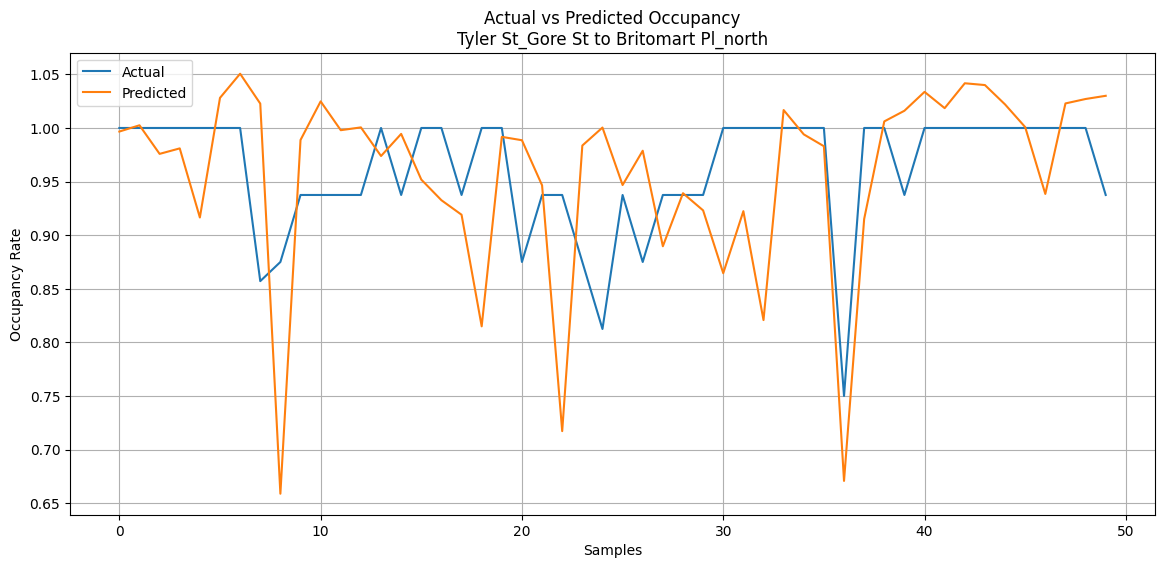

In [ ]:
##Plots below

import pandas as pd
import matplotlib.pyplot as plt

# predictions
pred_test = model.predict(X_test)

# create results dataframe
results_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": pred_test
}, index=y_test.index)

# recover location ids
results_df["location_id"] = akl_final_ready.loc[
    y_test.index,
    "location_id"
].values

# find most common location
top_location = results_df["location_id"].value_counts().idxmax()

print("Using location:", top_location)

# filter location
loc_df = results_df[
    results_df["location_id"] == top_location
].iloc[30:80]

# plot
plt.figure(figsize=(14,6))

plt.plot(
    loc_df["actual"].values,
    label="Actual"
)

plt.plot(
    loc_df["predicted"].values,
    label="Predicted"
)

plt.title(f"Actual vs Predicted Occupancy\n{top_location}")

plt.xlabel("Samples")
plt.ylabel("Occupancy Rate")

plt.legend()
plt.grid(True)

plt.show()

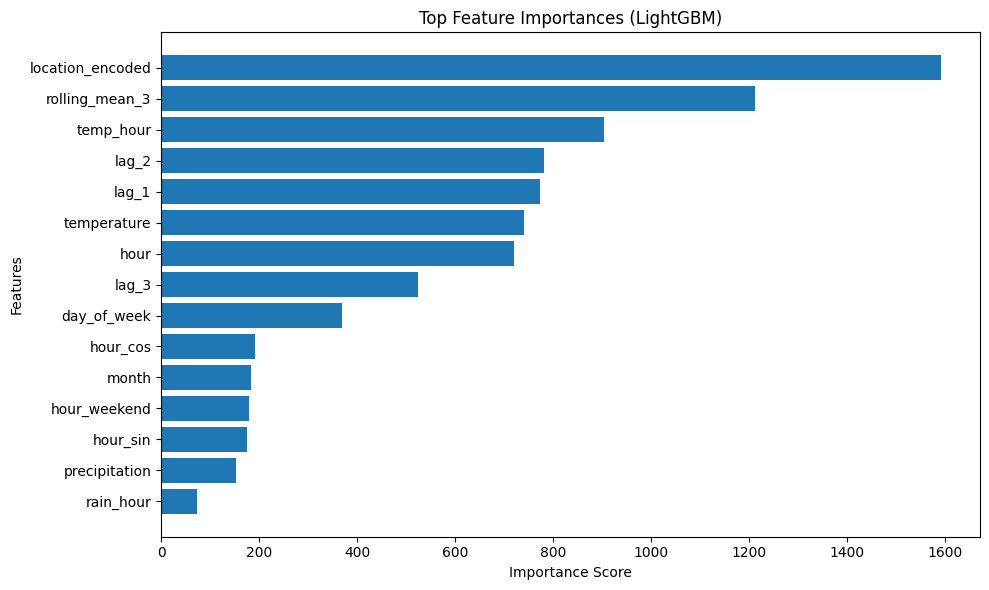

             feature  importance
0   location_encoded        1591
17    rolling_mean_3        1211
13         temp_hour         904
15             lag_2         782
14             lag_1         773
5        temperature         740
1               hour         719
16             lag_3         523
2        day_of_week         368
10          hour_cos         192
3              month         184
11      hour_weekend         179
9           hour_sin         175
6      precipitation         153
12         rain_hour          73


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# get feature names from training data
feature_names = X_train.columns

# create importance dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

# sort by importance
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

# show top features
top_n = 15

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["feature"][:top_n][::-1],
    importance_df["importance"][:top_n][::-1]
)

plt.title("Top Feature Importances (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# optional table
print(importance_df.head(15))

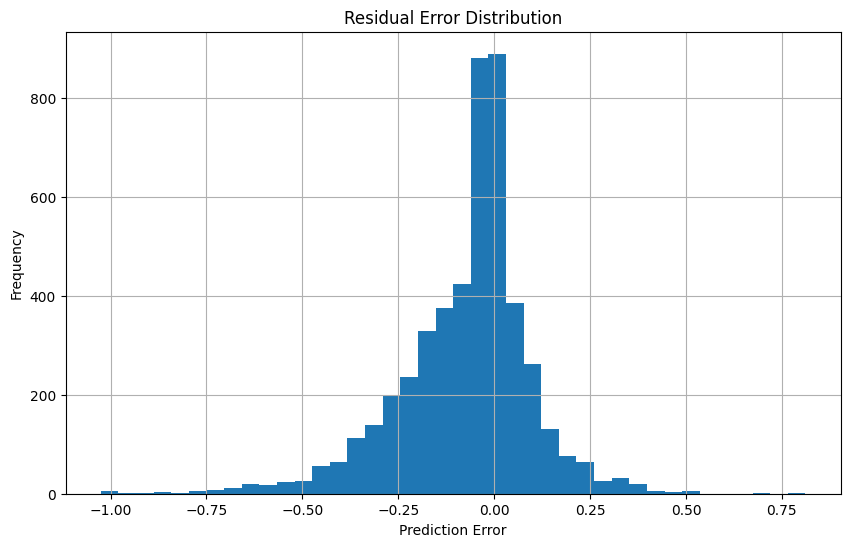

In [ ]:
import matplotlib.pyplot as plt

# predictions from main test set
pred_test = model.predict(X_test)

# residuals
residuals = y_test - pred_test

plt.figure(figsize=(10,6))

plt.hist(residuals, bins=40)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

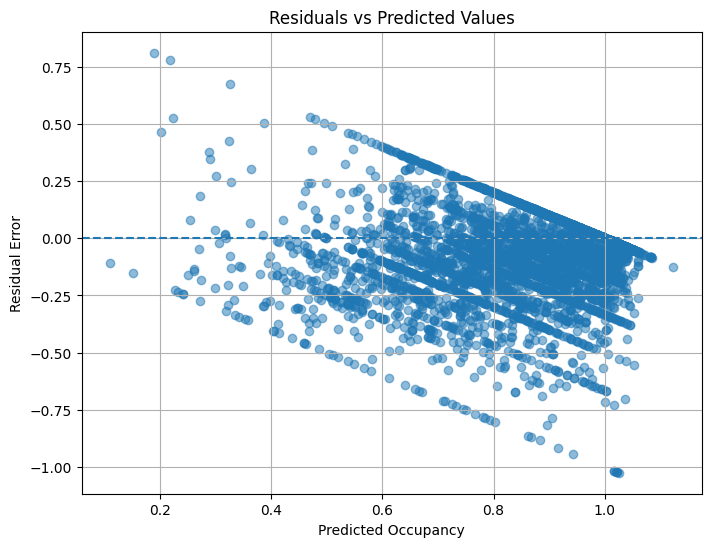

In [ ]:
import matplotlib.pyplot as plt

# generate predictions from main test set
pred_test = model.predict(X_test)

# residuals
residuals = y_test - pred_test

# scatter plot
plt.figure(figsize=(8,6))

plt.scatter(pred_test, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Occupancy")
plt.ylabel("Residual Error")

plt.grid(True)

plt.show()

In [ ]:
##next is dashboard (demo)

In [ ]:

# COMBINING

df = pd.concat([live_df, df_other_final], ignore_index=True)



# 3. COORDINATES


# exact coords for live locations
coords_live = {
    "Civic": (-36.85287832375424, 174.76297708090766),
    "Ronwood": (-36.99085483040531, 174.87838926318418),
    "Toka Puia": (-36.78989857570254, 174.7713089896234),
    "Victoria Street": (-36.84860593766831, 174.76805014004776)
}

# street-level approximate coords
street_coords = {
    "Adelaide St": (-36.84900346191156, 174.7558654343414),
    "Airedale St": (-36.85463225489937, 174.76508017666995),
    "Albert St": (-36.847264502582796, 174.7646146803715),
    "Anzac Ave": (-36.84741550285417, 174.77282127666965),
    "Bacons Ln": (-36.84769218889911, 174.7684538361922),
    "Bankside St": (-36.84740038840756, 174.76990706502815),
    "Beach Rd": (-36.84725507460195, 174.7737208962772),
    "Beaumont St": (-36.84440265519681, 174.7536310920129),
    "Beresford Sq": (-36.85647213456425, 174.7583923570889),
    "Bowen Ave": (-36.848777890727426, 174.76861030920742),
    "Canada St": (-36.859231724083784, 174.76011720735696),
    "Centre St": (-36.849062735028, 174.75538036502823),
    "Chancery St": (-36.84750690301815, 174.76884620920728),
    "Churchill St": (-36.85103565384606, 174.7743365073566),
    "City Rd": (-36.8566813040395, 174.76349486502858),
    "Commerce St": (-36.84470874034881, 174.76848564968458),
    "Cook St": (-36.85079060891733, 174.75791879571509),
    "Courthouse Ln": (-36.848093575078714, 174.7679820570885),
    "Cross St": (-36.85839625389392, 174.76060699571542),
    "Custom St": (-36.84470899280409, 174.7667333342052),
    "Customs St East": (-36.84501808450307, 174.76879327063108),
    "Customs St West": (-36.84420242315298, 174.76507036464886),
    "Daldy St": (-36.842929736554, 174.75552380735624),
    "Day St": (-36.85705666669267, 174.7571167496851),
    "Dock St": (-36.847857147065, 174.75753223249046),
    "Drake St": (-36.84850426299273, 174.7552329361924),
    "East St": (-36.85827517544595, 174.7584215766702),
    "Eden Cres": (-36.84790828926292, 174.7722451803715),
    "Emily Pl": (-36.84642524384168, 174.77092410550543),
    "Federal St": (-36.84781670357473, 174.76310933434138),
    "Galatos St": (-36.85844712267387, 174.7577683189985),
    "Galway St": (-36.84457979776017, 174.76908743619214),
    "Gaunt St": (-36.844182468931415, 174.75501254968466),
    "Gore St": (-36.84511681288865, 174.76933807852046),
    "Grafton Rd": (-36.85855398556348, 174.7688923766702),
    "Graham St": (-36.84697124517524, 174.75983265153562),
    "Greys Ave": (-36.85435943053094, 174.76119784968506),
    "Halsey St": (-36.84460128369381, 174.75733166502798),
    "Hardinge St": (-36.8468568018503, 174.75878392455084),
    "High St": (-36.84772373232186, 174.76686199016214),
    "Hobson St": (-36.84917830602086, 174.76155040735654),
    "Jellicoe St": (-36.84049271770917, 174.75639494968445),
    "Karangahape Rd": (-36.85753551167483, 174.75823227248605),
    "Kingston St": (-36.84733647388881, 174.7633097055054),
    "Kitchener St": (-36.84930310624497, 174.76709230550557),
    "Liverpool St": (-36.85736876467528, 174.76266836084437),
    "Lorne St": (-36.850959394401585, 174.76573807852077),
    "Lyndock St": (-36.854999931753625, 174.76530674783413),
    "Madden St": (-36.84264252269022, 174.75552131480947),
    "Madden st": (-36.84264252269022, 174.75552131480947),
    "Mahuhu Cres": (-36.84683804489097, 174.77486897666964),
    "Market Pl": (-36.84434449733736, 174.76182657666945),
    "Marmion St": (-36.85449143078289, 174.76409338037186),
    "Mayoral Dr": (-36.85330681343808, 174.7652604361926),
    "Mercury Ln": (-36.858341685086515, 174.7594160189985),
    "Mount St": (-36.85451281560479, 174.76703072270013),
    "Nelson St": (-36.8496642068938, 174.7595278343414),
    "Pakenham St East": (-36.84429652539574, 174.76091591290898),
    "Pakenham St West": (-36.84306683684642, 174.7560756650279),
    "Parliament St": (-36.84896039103498, 174.773309895715),
    "Pitt St": (-36.85591724652853, 174.75910711111203),
    "Poynton Tce": (-36.8568907818277, 174.76019570550596),
    "Princes St": (-36.84999492219959, 174.76967096873005),
    "Quay St": (-36.844950170138105, 174.77416436502796),
    "Queen St": (-36.850747737244376, 174.7651739626933),
    "Ronayne St": (-36.84934869168888, 174.77603897852063),
    "Sale St": (-36.84931275017033, 174.75587400365467),
    "Short St": (-36.847442988479415, 174.7717208361923),
    "Shortland St": (-36.846837658750566, 174.76881796502806),
    "South St": (-36.85902249225965, 174.75841189386452),
    "St James St": (-36.85543607130134, 174.7582337822227),
    "St Paul St": (-36.85373488394658, 174.76683472270017),
    "Sturdee St": (-36.84440673970444, 174.76284046502798),
    "Swanson St": (-36.845631756542254, 174.76452050920727),
    "Symonds St": (-36.85668541950836, 174.76563304783429),
    "Tangihua St": (-36.84551952786732, 174.77386136687898),
    "Tapora St": (-36.84598701454945, 174.7754742785205),
    "Te Taou Cres": (-36.84834578999973, 174.7769366110584),
    "Turner St": (-36.85540254784233, 174.76375040735678),
    "Tyler St": (-36.84401299674191, 174.7692313343412),
    "Union St": (-36.8514484100992, 174.75576303619255),
    "Upper Queen St": (-36.860417289748746, 174.7606412803722),
    "Vernon St": (-36.84923290611898, 174.7566831515358),
    "Viaduct Harbour Ave": (-36.84514351293956, 174.75888743619214),
    "Victoria St West": (-36.847813761442055, 174.758279518998),
    "Vincent St": (-36.85343037405558, 174.7603303957153),
    "Wakefield St": (-36.854081045171114, 174.76579229571524),
    "Waterloo Quad": (-36.848994076494286, 174.7717209552376),
    "Waverlay St": (-36.854931846890736, 174.76437528222277),
    "Wellesley St East": (-36.85218265159879, 174.76721468037178),
    "Wellesley St West": (-36.84954597736182, 174.7607884803716),
    "West Tce": (-36.85825693797179, 174.7571178110588),
    "Westhaven Dr": (-36.84084011841113, 174.74619709571462),
    "Whitaker Pl": (-36.85656820950296, 174.76593058597825),
    "White St": (-36.85494714692177, 174.76457223434176),
    "Wolfe St": (-36.844727512145674, 174.76457129386378),
    "Wyndham St": (-36.84654878697347, 174.76384349571484),
}



# 3) FUNCTION TO EXTRACT STREET NAME

def extract_street(loc):

    return loc.split("_")[0]



# 4) ASSIGNING LAT/LON

def get_coords(loc):
    # priority 1 - exact live location
    if loc in coords_live:
        return coords_live[loc]

    # priority 2 - street-level
    street = extract_street(loc)
    if street in street_coords:
        return street_coords[street]

    # fallback - CBD center
    return (-36.8485, 174.7633)


df["lat"] = df["location_id"].map(lambda x: get_coords(x)[0])
df["lon"] = df["location_id"].map(lambda x: get_coords(x)[1])


print(df.head(5))

                            location_id  available_spaces  total_spaces  \
0                                 Civic             531.0         930.0   
1                               Ronwood             528.0         678.0   
2                             Toka Puia             305.0         420.0   
3                       Victoria Street             548.0         895.0   
4  Adelaide St_Drake St to Sale St_east               NaN           NaN   

   occupancy_now  hour  day_of_week  month  is_weekend  hour_sin  hour_cos  \
0       0.429032   1.0          6.0    5.0         1.0  0.258819  0.965926   
1       0.221239   1.0          6.0    5.0         1.0  0.258819  0.965926   
2       0.273810   1.0          6.0    5.0         1.0  0.258819  0.965926   
3       0.387709   1.0          6.0    5.0         1.0  0.258819  0.965926   
4       0.666667   NaN          NaN    NaN         NaN       NaN       NaN   

   ...  precipitation  is_rain  rain_level  rain_hour  temp_hour  \
0  ...      

In [ ]:

# FULL AUCKLAND MAP VISUALIZATION (FINAL)


import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go



# 1. COMBINE DATA

df = pd.concat([live_df, df_other_final], ignore_index=True)



# 2. DEFINE LIVE LOCATIONS

live_locations = ["Civic", "Ronwood", "Toka Puia", "Victoria Street"]

df["is_live"] = df["location_id"].isin(live_locations)


def extract_street(loc):
    return loc.split("_")[0]

def get_coords(loc):
    if loc in coords_live:
        return coords_live[loc]

    street = extract_street(loc)
    if street in street_coords:
        return street_coords[street]

    return (-36.8485, 174.7633)  # fallback


df["lat"] = df["location_id"].map(lambda x: get_coords(x)[0])
df["lon"] = df["location_id"].map(lambda x: get_coords(x)[1])

df["street"] = df["location_id"].apply(lambda x: str(x).split("_")[0])


# 4. PRE-CLEAN


# clip values to valid range
df["predicted_next_hour"] = df["predicted_next_hour"].clip(0, 1)
df["occupancy_now"] = df["occupancy_now"].clip(0, 1)



# 5. CREATE LEVEL LABELS


def get_level(x):
    if x < 0.3:
        return "Low"
    elif x < 0.7:
        return "Medium"
    else:
        return "High"

df["occupancy_level"] = df["predicted_next_hour"].apply(get_level)



# 6. BASE MAP (CATEGORICAL COLORS)


fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="occupancy_level",   # category instead of numeric
    size="predicted_next_hour",
    hover_name="street",

    custom_data=[
        "occupancy_now",
        "predicted_next_hour",
        "predicted_cars",
        "occupancy_level"
    ],

    color_discrete_map={
        "Low": "green",
        "Medium": "orange",
        "High": "red"
    },

    zoom=15,
    height=600
)



# 7. HOVER FORMAT (CLEAN + 2 DECIMALS)


fig.update_traces(
    hovertemplate=
    "<b>%{hovertext}</b><br>" +
    "Level: %{customdata[3]}<br>" +
    "Current: %{customdata[0]:.2f}<br>" +
    "Predicted: %{customdata[1]:.2f}<br>" +
    "Cars: %{customdata[2]:.0f}<extra></extra>"
)



# 8. LIVE LOCATION HIGHLIGHT


live_df_plot = df[df["is_live"]]

# outer blue ring
fig.add_trace(go.Scattermapbox(
    lat=live_df_plot["lat"],
    lon=live_df_plot["lon"],
    mode="markers",
    marker=dict(size=18, color="blue", opacity=0.8),
    showlegend=False,
    hoverinfo="skip"
))

# inner colored dot
fig.add_trace(go.Scattermapbox(
    lat=live_df_plot["lat"],
    lon=live_df_plot["lon"],
    mode="markers",
    marker=dict(
        size=14,
        color=live_df_plot["occupancy_level"].map({
            "Low": "green",
            "Medium": "orange",
            "High": "red"
        })
    ),
    showlegend=False,   #  prevents duplicate legend
    hoverinfo="skip"
))



# 9. ADDING "P" LABELS


fig.add_trace(go.Scattermapbox(
    lat=df["lat"],
    lon=df["lon"],
    mode="text",
    text=["P"] * len(df),
    textfont=dict(size=12, color="black"),
    showlegend=False,
    hoverinfo="skip"
))



# 10. FINAL LAYOUT


fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=-36.8485, lon=174.7633),
        zoom=14
    ),
    margin={"r":0,"t":40,"l":0,"b":0},
    legend_title="Occupancy Level"
)


fig.show()

In [ ]:
# ============================================================
# ONE CSV EXPORT FOR POWER BI
# HISTORICAL + LIVE API + ML FORECAST
# POWER BI NUMERIC-COMPATIBLE VERSION
# ============================================================

import pandas as pd
import numpy as np
import requests
import time
from bs4 import BeautifulSoup
from datetime import timedelta
from pathlib import Path

output_path = "/content/drive/MyDrive/ParkingProject/data/parking_powerbi_dashboard.csv"

name_fix_map = {
    "Victoria St": "Victoria Street"
}

total_spaces_map = {
    "Civic": 930,
    "Ronwood": 678,
    "Toka Puia": 420,
    "Victoria Street": 895
}

def demand_level_from_percent(x):
    if pd.isna(x):
        return "Unknown"
    if x >= 70:
        return "High"
    elif x >= 30:
        return "Medium"
    else:
        return "Low"

def extract_street(loc):
    return str(loc).split("_")[0]

def safe_coords(loc):
    try:
        return get_coords(loc)
    except:
        return (-36.8485, 174.7633)

def build_powerbi_dataset():

    # ========================================================
    # COMMON MODEL SETTINGS
    # ========================================================

    location_map = dict(zip(le.classes_, le.transform(le.classes_)))

    features_nolag = [
        "location_encoded",
        "hour", "day_of_week", "month", "is_weekend",
        "temperature", "precipitation", "is_rain", "rain_level",
        "hour_sin", "hour_cos", "hour_weekend", "rain_hour", "temp_hour"
    ]

    # ========================================================
    # 1. HISTORICAL DATA
    # ========================================================

    hist = akl_big.copy()

    hist["timestamp"] = pd.to_datetime(hist["timestamp_hour"])
    hist["date"] = hist["timestamp"].dt.date
    hist["street"] = hist["location_id"].apply(extract_street)

    hist["lat"] = hist["location_id"].map(lambda x: safe_coords(x)[0])
    hist["lon"] = hist["location_id"].map(lambda x: safe_coords(x)[1])

    hist["occupancy_rate"] = (hist["occupancy_rate"] * 100).clip(0, 100).round(2)
    hist["availability_rate"] = (100 - hist["occupancy_rate"]).round(2)

    hist["predicted_occupancy_rate"] = 0
    hist["forecast_lower"] = 0
    hist["forecast_upper"] = 0

    hist["available_spaces"] = 0
    hist["total_spaces"] = 0
    hist["cars"] = 0
    hist["predicted_cars"] = 0

    hist["demand_level"] = hist["occupancy_rate"].apply(demand_level_from_percent)

    hist["day_name"] = hist["timestamp"].dt.day_name()
    hist["hour"] = hist["timestamp"].dt.hour
    hist["month"] = hist["timestamp"].dt.month
    hist["is_weekend"] = hist["timestamp"].dt.dayofweek.isin([5, 6]).astype(int)

    hist["data_type"] = "Historical"
    hist["last_updated"] = pd.Timestamp.now()
    hist["api_status"] = "Historical Data"
    hist["parking_type"] = "Historical"

    hist["current_occupancy"] = hist["occupancy_rate"]
    hist["predicted_next"] = hist["predicted_occupancy_rate"]
    hist["predicted_next_hour"] = hist["predicted_occupancy_rate"]

    # ========================================================
    # 2. LIVE API DATA
    # ========================================================

    url = "https://at.govt.nz/umbraco/surface/parkingavailabilitysurface/ParkingAvailabilityResult"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers, timeout=30)
    soup = BeautifulSoup(response.text, "html.parser")
    rows = soup.find_all("div", class_="divTableRow")

    live_rows = []

    for row in rows:
        cells = row.find_all("div", class_="divTableCell")

        if len(cells) < 3:
            continue

        location = cells[0].get_text(strip=True)
        ptype = cells[1].get_text(strip=True)
        available = cells[2].get_text(strip=True)

        if location == "Car park":
            continue

        if ptype != "Short-term":
            continue

        available = (
            str(available)
            .replace(",", "")
            .replace("spaces", "")
            .strip()
        )

        try:
            available = int(float(available))
        except:
            continue

        location = name_fix_map.get(location, location)

        if location not in total_spaces_map:
            continue

        live_rows.append({
            "location_id": location,
            "street": location,
            "parking_type": ptype,
            "available_spaces": available,
            "total_spaces": total_spaces_map[location]
        })

    live = pd.DataFrame(live_rows)

    if len(live) > 0:

        now = pd.Timestamp.now().floor("min")
        future_time = now + timedelta(hours=1)

        live["timestamp"] = now
        live["date"] = now.date()
        live["last_updated"] = now

        live["available_spaces"] = pd.to_numeric(
            live["available_spaces"],
            errors="coerce"
        ).fillna(0)

        live["total_spaces"] = pd.to_numeric(
            live["total_spaces"],
            errors="coerce"
        ).fillna(0)

        live["occupancy_now"] = (
            1 - (live["available_spaces"] / live["total_spaces"])
        ).clip(0, 1)

        live["occupancy_rate"] = (live["occupancy_now"] * 100).round(2)
        live["availability_rate"] = (100 - live["occupancy_rate"]).round(2)

        live["hour"] = future_time.hour
        live["day_of_week"] = future_time.dayofweek
        live["month"] = future_time.month
        live["is_weekend"] = 1 if future_time.dayofweek >= 5 else 0

        live["hour_sin"] = np.sin(2 * np.pi * live["hour"] / 24)
        live["hour_cos"] = np.cos(2 * np.pi * live["hour"] / 24)
        live["hour_weekend"] = live["hour"] * live["is_weekend"]

        latest = akl_big.sort_values("timestamp_hour").iloc[-1]

        live["temperature"] = latest["temperature"]
        live["precipitation"] = latest["precipitation"]
        live["is_rain"] = latest["is_rain"]
        live["rain_level"] = latest["rain_level"]

        live["rain_hour"] = live["hour"] * live["is_rain"]
        live["temp_hour"] = live["hour"] * live["temperature"]

        live["location_encoded"] = live["location_id"].map(location_map).fillna(-1)

        pred_live = model_nolag.predict(live[features_nolag])
        pred_live = np.clip(pred_live, 0, 1)

        max_change = 0.2 + 0.3 * live["is_weekend"]

        pred_live = np.clip(
            pred_live,
            live["occupancy_now"] - max_change,
            live["occupancy_now"] + max_change
        )

        live["predicted_occupancy_rate"] = (pred_live * 100).round(2)
        live["forecast_lower"] = (live["predicted_occupancy_rate"] - 5).clip(0, 100)
        live["forecast_upper"] = (live["predicted_occupancy_rate"] + 5).clip(0, 100)

        live["cars"] = (
            live["occupancy_now"] * live["total_spaces"]
        ).round(0)

        live["predicted_cars"] = (
            pred_live * live["total_spaces"]
        ).round(0)

        live["lat"] = live["location_id"].map(lambda x: safe_coords(x)[0])
        live["lon"] = live["location_id"].map(lambda x: safe_coords(x)[1])

        live["demand_level"] = live["predicted_occupancy_rate"].apply(
            demand_level_from_percent
        )

        live["day_name"] = pd.to_datetime(live["timestamp"]).dt.day_name()

        live["data_type"] = "Live"
        live["api_status"] = "Connected"

        live["current_occupancy"] = live["occupancy_rate"]
        live["predicted_next"] = live["predicted_occupancy_rate"]
        live["predicted_next_hour"] = live["predicted_occupancy_rate"]

    else:
        live = pd.DataFrame()

    # ========================================================
    # 3. FUTURE FORECAST DATA — NEXT 24 HOURS
    # ========================================================

    latest_time = pd.Timestamp.now().floor("h")
    all_locations = akl_big["location_id"].unique()

    future_rows = []

    latest_hist = (
        akl_big.sort_values("timestamp_hour")
        .groupby("location_id")
        .tail(1)
    )

    latest_lookup = latest_hist.set_index("location_id")

    for loc in all_locations:

        if loc not in latest_lookup.index:
            continue

        base_row = latest_lookup.loc[loc]

        for h in range(1, 25):

            future_ts = latest_time + timedelta(hours=h)

            row = {
                "location_id": loc,
                "street": extract_street(loc),
                "timestamp": future_ts,
                "date": future_ts.date(),
                "hour": future_ts.hour,
                "day_of_week": future_ts.dayofweek,
                "month": future_ts.month,
                "is_weekend": 1 if future_ts.dayofweek >= 5 else 0,
                "temperature": base_row["temperature"],
                "precipitation": base_row["precipitation"],
                "is_rain": base_row["is_rain"],
                "rain_level": base_row["rain_level"]
            }

            row["hour_sin"] = np.sin(2 * np.pi * row["hour"] / 24)
            row["hour_cos"] = np.cos(2 * np.pi * row["hour"] / 24)
            row["hour_weekend"] = row["hour"] * row["is_weekend"]
            row["rain_hour"] = row["hour"] * row["is_rain"]
            row["temp_hour"] = row["hour"] * row["temperature"]

            row["location_encoded"] = location_map.get(loc, -1)

            future_rows.append(row)

    forecast = pd.DataFrame(future_rows)

    if len(forecast) > 0:

        pred_forecast = model_nolag.predict(forecast[features_nolag])
        pred_forecast = np.clip(pred_forecast, 0, 1)

        forecast["occupancy_rate"] = 0
        forecast["availability_rate"] = 0

        forecast["predicted_occupancy_rate"] = (pred_forecast * 100).round(2)
        forecast["forecast_lower"] = (forecast["predicted_occupancy_rate"] - 5).clip(0, 100)
        forecast["forecast_upper"] = (forecast["predicted_occupancy_rate"] + 5).clip(0, 100)

        forecast["total_spaces"] = forecast["location_id"].map(total_spaces_map).fillna(0)
        forecast["available_spaces"] = (
            forecast["total_spaces"] *
            (1 - forecast["predicted_occupancy_rate"] / 100)
        ).round(0)

        forecast["cars"] = 0
        forecast["predicted_cars"] = (
            forecast["total_spaces"] *
            forecast["predicted_occupancy_rate"] / 100
        ).round(0)

        forecast["lat"] = forecast["location_id"].map(lambda x: safe_coords(x)[0])
        forecast["lon"] = forecast["location_id"].map(lambda x: safe_coords(x)[1])

        forecast["demand_level"] = forecast["predicted_occupancy_rate"].apply(
            demand_level_from_percent
        )

        forecast["day_name"] = pd.to_datetime(forecast["timestamp"]).dt.day_name()

        forecast["data_type"] = "Forecast"
        forecast["last_updated"] = pd.Timestamp.now()
        forecast["api_status"] = "Forecast"
        forecast["parking_type"] = "Forecast"

        forecast["current_occupancy"] = forecast["occupancy_rate"]
        forecast["predicted_next"] = forecast["predicted_occupancy_rate"]
        forecast["predicted_next_hour"] = forecast["predicted_occupancy_rate"]

    else:
        forecast = pd.DataFrame()

    # ========================================================
    # 4. FINAL UNIFIED DATASET
    # ========================================================

    final_columns = [
        "timestamp",
        "date",
        "location_id",
        "street",
        "lat",
        "lon",
        "occupancy_rate",
        "availability_rate",
        "current_occupancy",
        "predicted_occupancy_rate",
        "predicted_next",
        "predicted_next_hour",
        "forecast_lower",
        "forecast_upper",
        "available_spaces",
        "total_spaces",
        "cars",
        "predicted_cars",
        "demand_level",
        "day_name",
        "hour",
        "month",
        "is_weekend",
        "data_type",
        "last_updated",
        "api_status",
        "parking_type"
    ]

    combined = pd.concat(
        [hist, live, forecast],
        ignore_index=True
    )

    for col in final_columns:
        if col not in combined.columns:
            combined[col] = 0 if col in [
                "occupancy_rate",
                "availability_rate",
                "current_occupancy",
                "predicted_occupancy_rate",
                "predicted_next",
                "predicted_next_hour",
                "forecast_lower",
                "forecast_upper",
                "available_spaces",
                "total_spaces",
                "cars",
                "predicted_cars",
                "lat",
                "lon",
                "hour",
                "month",
                "is_weekend"
            ] else ""

    combined = combined[final_columns]

    # ========================================================
    # 5. FINAL POWER BI DATA TYPE CLEANING
    # ========================================================

    numeric_cols = [
        "lat",
        "lon",
        "occupancy_rate",
        "availability_rate",
        "current_occupancy",
        "predicted_occupancy_rate",
        "predicted_next",
        "predicted_next_hour",
        "forecast_lower",
        "forecast_upper",
        "available_spaces",
        "total_spaces",
        "cars",
        "predicted_cars",
        "hour",
        "month",
        "is_weekend"
    ]

    for col in numeric_cols:
        combined[col] = pd.to_numeric(
            combined[col],
            errors="coerce"
        ).fillna(0)

    integer_cols = [
        "available_spaces",
        "total_spaces",
        "cars",
        "predicted_cars",
        "hour",
        "month",
        "is_weekend"
    ]

    for col in integer_cols:
        combined[col] = combined[col].round(0).astype(int)

    decimal_cols = [
        "lat",
        "lon",
        "occupancy_rate",
        "availability_rate",
        "current_occupancy",
        "predicted_occupancy_rate",
        "predicted_next",
        "predicted_next_hour",
        "forecast_lower",
        "forecast_upper"
    ]

    for col in decimal_cols:
        combined[col] = combined[col].round(2)

    combined["timestamp"] = pd.to_datetime(combined["timestamp"])
    combined["last_updated"] = pd.to_datetime(combined["last_updated"])

    combined = combined.sort_values(
        by=["timestamp", "data_type", "street"]
    )

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)

    combined.to_csv(output_path, index=False)

    print("CSV exported successfully:")
    print(output_path)

    print("\nRows by data_type:")
    print(combined["data_type"].value_counts())

    print("\nData types:")
    print(combined.dtypes)

    print("\nLive rows:")
    print(
        combined[combined["data_type"] == "Live"][
            [
                "street",
                "occupancy_rate",
                "available_spaces",
                "total_spaces",
                "predicted_occupancy_rate"
            ]
        ]
    )

    return combined


# ============================================================
# RUN ONCE
# ============================================================

parking_powerbi_dashboard = build_powerbi_dataset()


# ============================================================
# OPTIONAL: AUTO UPDATE EVERY 5 MINUTES
# Run this only when ready
# ============================================================

# while True:
#     parking_powerbi_dashboard = build_powerbi_dataset()
#     print("Waiting 5 minutes...")
#     time.sleep(300)